# Gestion du Déséquilibre des Classes
## Analyse, Rééchantillonnage et Validation Croisée Stratifiée

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    f1_score, recall_score, precision_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve
)
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

from src.preprocessing import load_data, split_data, NUMERIC_FEATURES, CATEGORICAL_FEATURES

sns.set_theme(style='whitegrid')

df = load_data('../data/raw/customer_churn.csv')
X_train, X_test, y_train, y_test = split_data(df)
print(f'Train : {len(X_train)} | Test : {len(X_test)}')

Train : 8000 | Test : 2000


## 1. Analyse Préalable du Déséquilibre

Classe majoritaire (No Churn) : 7183 (89.8%)
Classe minoritaire (Churn)    : 817 (10.2%)
Ratio de déséquilibre         : 8.8:1

=> Déséquilibre SIGNIFICATIF : un modèle naïf peut atteindre 89.8% d'accuracy
   en prédisant toujours "No Churn", sans jamais détecter un seul churner.


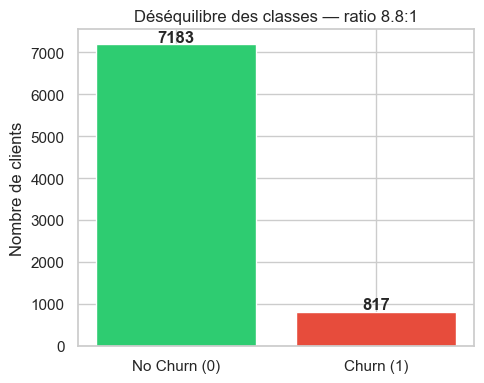

In [2]:
majority = (y_train == 0).sum()
minority = (y_train == 1).sum()
ratio = majority / minority

print(f'Classe majoritaire (No Churn) : {majority} ({majority/len(y_train):.1%})')
print(f'Classe minoritaire (Churn)    : {minority} ({minority/len(y_train):.1%})')
print(f'Ratio de déséquilibre         : {ratio:.1f}:1')
print()
print('=> Déséquilibre SIGNIFICATIF : un modèle naïf peut atteindre', f'{majority/len(y_train):.1%}', "d'accuracy")
print('   en prédisant toujours "No Churn", sans jamais détecter un seul churner.')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['No Churn (0)', 'Churn (1)'], [majority, minority], color=['#2ecc71', '#e74c3c'])
ax.set_title(f'Déséquilibre des classes — ratio {ratio:.1f}:1')
ax.set_ylabel('Nombre de clients')
for i, v in enumerate([majority, minority]):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Insuffisance de l'Accuracy — Démonstration par le Baseline Naïf

=== Modèle Baseline Naïf (prédit toujours No Churn) ===
Accuracy  : 0.898  <-- paraît excellent !
Recall    : 0.000   <-- détecte 0 churner
F1-score  : 0.000   <-- inutile en pratique

=> Conclusion : l'accuracy est une métrique TROMPEUSE ici.
   Les métriques pertinentes sont : Recall, F1, ROC-AUC, PR-AUC

Justification métier :
  - Un faux négatif (churner non détecté) = perte de revenu garantie
  - Un faux positif (client ciblé à tort) = coût d'action marketing faible
  => Maximiser le Recall est prioritaire, avec un F1 acceptable


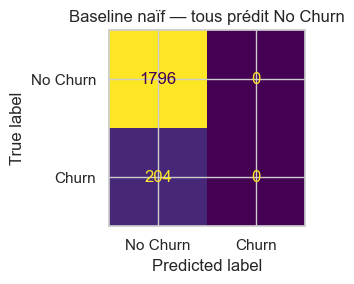

In [3]:
# Modèle naïf : prédit toujours 0 (No Churn)
y_naive = np.zeros(len(y_test), dtype=int)

naive_accuracy = (y_naive == y_test).mean()
naive_recall   = recall_score(y_test, y_naive, zero_division=0)
naive_f1       = f1_score(y_test, y_naive, zero_division=0)

print('=== Modèle Baseline Naïf (prédit toujours No Churn) ===')
print(f'Accuracy  : {naive_accuracy:.3f}  <-- paraît excellent !')
print(f'Recall    : {naive_recall:.3f}   <-- détecte 0 churner')
print(f'F1-score  : {naive_f1:.3f}   <-- inutile en pratique')
print()
print('=> Conclusion : l\'accuracy est une métrique TROMPEUSE ici.')
print('   Les métriques pertinentes sont : Recall, F1, ROC-AUC, PR-AUC')
print()
print('Justification métier :')
print('  - Un faux négatif (churner non détecté) = perte de revenu garantie')
print('  - Un faux positif (client ciblé à tort) = coût d\'action marketing faible')
print('  => Maximiser le Recall est prioritaire, avec un F1 acceptable')

# Matrice de confusion du baseline
fig, ax = plt.subplots(figsize=(4, 3))
cm = confusion_matrix(y_test, y_naive)
ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(ax=ax, colorbar=False)
ax.set_title('Baseline naïf — tous prédit No Churn')
plt.tight_layout()
plt.show()

## 3. Construction du Preprocessor Commun

In [4]:
def build_preprocessor():
    num_pipe = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc', StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    return ColumnTransformer([
        ('num', num_pipe, NUMERIC_FEATURES),
        ('cat', cat_pipe, CATEGORICAL_FEATURES),
    ])

def find_best_threshold(y_true, y_proba):
    thresholds = np.arange(0.05, 0.95, 0.01)
    f1s = [f1_score(y_true, y_proba >= t, zero_division=0) for t in thresholds]
    return float(thresholds[np.argmax(f1s)])

def evaluate(name, pipeline, X_tr, y_tr, X_te, y_te):
    pipeline.fit(X_tr, y_tr)
    y_proba = pipeline.predict_proba(X_te)[:, 1]
    thr = find_best_threshold(y_te, y_proba)
    y_pred = (y_proba >= thr).astype(int)
    return {
        'stratégie': name,
        'precision': round(precision_score(y_te, y_pred, zero_division=0), 3),
        'recall':    round(recall_score(y_te, y_pred, zero_division=0), 3),
        'f1':        round(f1_score(y_te, y_pred, zero_division=0), 3),
        'roc_auc':   round(roc_auc_score(y_te, y_proba), 3),
        'pr_auc':    round(average_precision_score(y_te, y_proba), 3),
        'seuil':     round(thr, 2),
    }, pipeline

print('Preprocessor et fonctions utilitaires prêts.')

Preprocessor et fonctions utilitaires prêts.


## 4. Comparaison des Techniques de Rééchantillonnage (Data-Level)

Modèle utilisé pour la comparaison : **Logistic Regression** (rapide, interprétable, bon baseline).

In [5]:
strategies = {
    'Baseline (class_weight=balanced)': ImbPipeline([
        ('pre', build_preprocessor()),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
    ]),
    'Random Over-Sampling': ImbPipeline([
        ('pre', build_preprocessor()),
        ('sampler', RandomOverSampler(random_state=42)),
        ('clf', LogisticRegression(max_iter=1000, random_state=42)),
    ]),
    'SMOTE': ImbPipeline([
        ('pre', build_preprocessor()),
        ('sampler', SMOTE(random_state=42, k_neighbors=5)),
        ('clf', LogisticRegression(max_iter=1000, random_state=42)),
    ]),
    'Random Under-Sampling': ImbPipeline([
        ('pre', build_preprocessor()),
        ('sampler', RandomUnderSampler(random_state=42)),
        ('clf', LogisticRegression(max_iter=1000, random_state=42)),
    ]),
}

results = []
trained_pipelines = {}
for name, pipe in strategies.items():
    row, trained = evaluate(name, pipe, X_train, y_train, X_test, y_test)
    results.append(row)
    trained_pipelines[name] = trained
    print(f"{name}: recall={row['recall']}, f1={row['f1']}, pr_auc={row['pr_auc']}")

results_df = pd.DataFrame(results).set_index('stratégie')
print()
display(results_df.style.highlight_max(axis=0, color='#d4efdf').format('{:.3f}', subset=['precision','recall','f1','roc_auc','pr_auc']))

Baseline (class_weight=balanced): recall=0.387, f1=0.317, pr_auc=0.24


Random Over-Sampling: recall=0.407, f1=0.309, pr_auc=0.235


SMOTE: recall=0.515, f1=0.303, pr_auc=0.236
Random Under-Sampling: recall=0.402, f1=0.314, pr_auc=0.225



,precision,recall,f1,roc_auc,pr_auc,seuil
stratégie,,,,,,
Baseline (class_weight=balanced),0.268,0.387,0.317,0.724,0.240,0.670000
Random Over-Sampling,0.249,0.407,0.309,0.720,0.235,0.650000
SMOTE,0.215,0.515,0.303,0.714,0.236,0.590000
Random Under-Sampling,0.258,0.402,0.314,0.715,0.225,0.670000


## 5. Visualisation — Courbes Precision-Recall par Stratégie

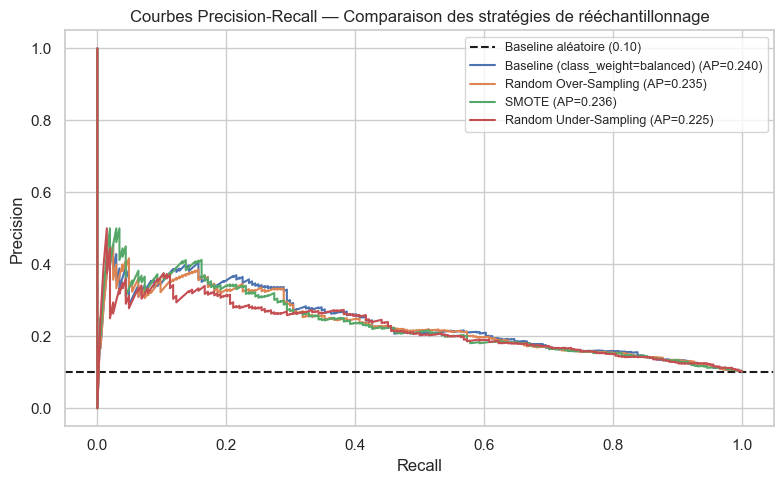

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
baseline_rate = y_test.mean()
ax.axhline(baseline_rate, color='k', linestyle='--', label=f'Baseline aléatoire ({baseline_rate:.2f})')

for name, pipe in trained_pipelines.items():
    y_proba = pipe.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    ax.plot(rec, prec, label=f'{name} (AP={ap:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Courbes Precision-Recall — Comparaison des stratégies de rééchantillonnage')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 6. Matrices de Confusion par Stratégie

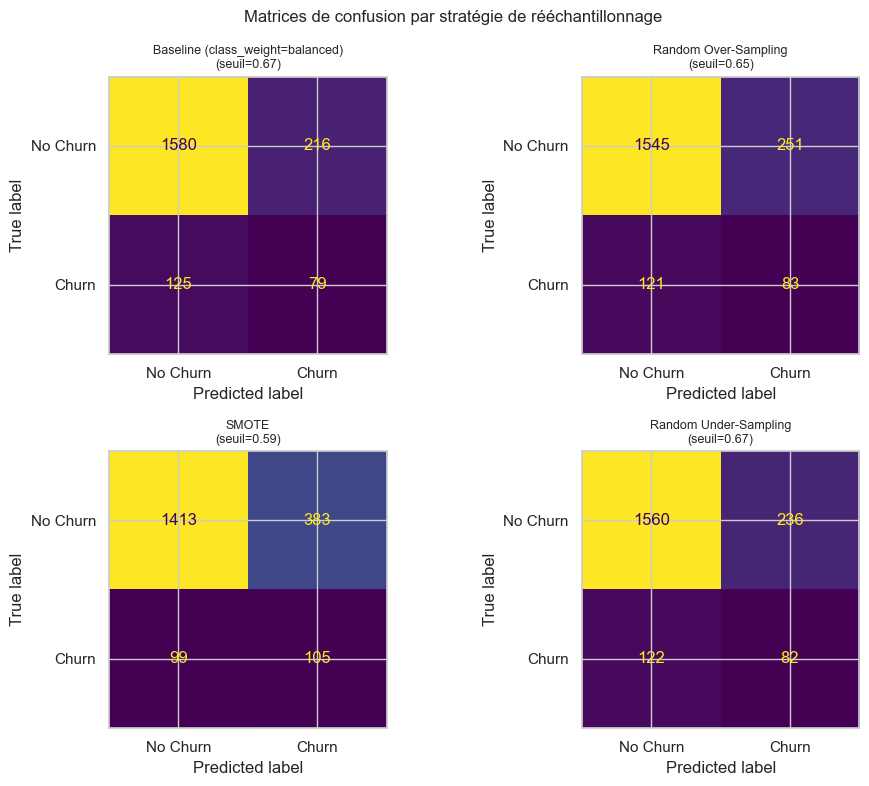

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (name, pipe) in zip(axes.flatten(), trained_pipelines.items()):
    y_proba = pipe.predict_proba(X_test)[:, 1]
    thr = find_best_threshold(y_test, y_proba)
    y_pred = (y_proba >= thr).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(ax=ax, colorbar=False)
    ax.set_title(f'{name}\n(seuil={thr:.2f})', fontsize=9)
plt.suptitle('Matrices de confusion par stratégie de rééchantillonnage', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Analyse des Effets de Chaque Technique

| Technique | Avantages | Inconvénients |
|---|---|---|
| **class_weight=balanced** | Simple, pas de modification du dataset, pas d'overfitting | Moins agressif, recall limité |
| **Random Over-Sampling** | Augmente la minorité sans perte de données | Risque d'overfitting (doublons exacts) |
| **SMOTE** | Génère des exemples synthétiques, plus robuste que ROS | Peut introduire du bruit si les classes se chevauchent |
| **Random Under-Sampling** | Équilibre rapide, réduit le temps d'entraînement | Perte d'information de la classe majoritaire |

## 8. Validation Croisée Stratifiée (Stratified K-Fold, k=5)

La **validation croisée stratifiée** est essentielle en contexte de déséquilibre : elle garantit que chaque fold conserve le même ratio de classes (10,2% de churners) que le dataset complet, évitant ainsi les splits où la minorité est sous-représentée.

In [8]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_strategies = {
    'class_weight=balanced': ImbPipeline([
        ('pre', build_preprocessor()),
        ('clf', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ]),
    'SMOTE': ImbPipeline([
        ('pre', build_preprocessor()),
        ('sampler', SMOTE(random_state=42)),
        ('clf', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ]),
    'Random Under-Sampling': ImbPipeline([
        ('pre', build_preprocessor()),
        ('sampler', RandomUnderSampler(random_state=42)),
        ('clf', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ]),
}

cv_results = []
for name, pipe in cv_strategies.items():
    scores = cross_validate(
        pipe, X_train, y_train,
        cv=skf,
        scoring=['f1', 'roc_auc', 'average_precision'],
        n_jobs=-1,
    )
    cv_results.append({
        'stratégie': name,
        'F1 moyen': f"{scores['test_f1'].mean():.3f}",
        'F1 std': f"± {scores['test_f1'].std():.3f}",
        'ROC-AUC moyen': f"{scores['test_roc_auc'].mean():.3f}",
        'PR-AUC moyen': f"{scores['test_average_precision'].mean():.3f}",
    })
    print(f"{name}: F1={scores['test_f1'].mean():.3f} ± {scores['test_f1'].std():.3f} | ROC-AUC={scores['test_roc_auc'].mean():.3f} | PR-AUC={scores['test_average_precision'].mean():.3f}")

cv_df = pd.DataFrame(cv_results).set_index('stratégie')
display(cv_df)

class_weight=balanced: F1=0.128 ± 0.014 | ROC-AUC=0.803 | PR-AUC=0.295


SMOTE: F1=0.074 ± 0.022 | ROC-AUC=0.793 | PR-AUC=0.264


Random Under-Sampling: F1=0.384 ± 0.010 | ROC-AUC=0.796 | PR-AUC=0.276


,F1 moyen,F1 std,ROC-AUC moyen,PR-AUC moyen
stratégie,,,,
class_weight=balanced,0.128,± 0.014,0.803,0.295
SMOTE,0.074,± 0.022,0.793,0.264
Random Under-Sampling,0.384,± 0.010,0.796,0.276


## 9. Analyse de l'Impact du Seuil de Décision

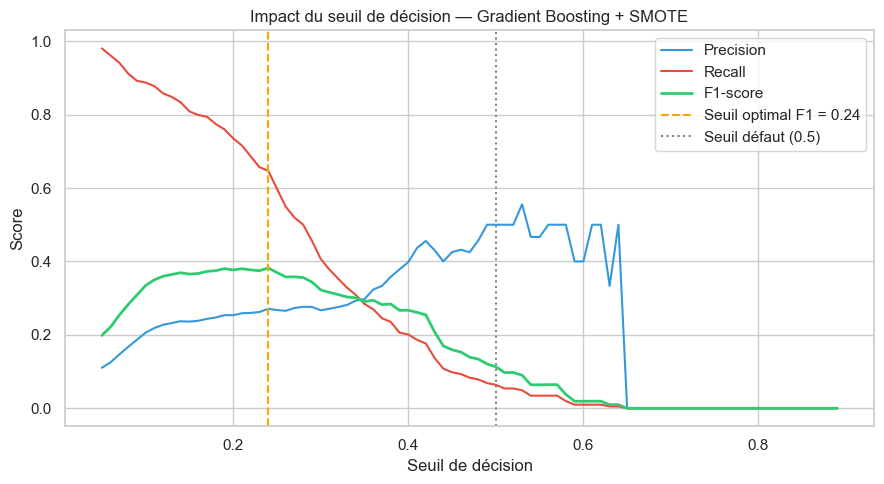

Seuil par défaut (0.5) => F1=0.113
Seuil optimal (0.24) => F1=0.382, Recall=0.647, Precision=0.271


In [9]:
# Sur le meilleur modèle (Gradient Boosting + SMOTE)
best_pipe = ImbPipeline([
    ('pre', build_preprocessor()),
    ('sampler', SMOTE(random_state=42)),
    ('clf', GradientBoostingClassifier(n_estimators=100, random_state=42)),
])
best_pipe.fit(X_train, y_train)
y_proba = best_pipe.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.05, 0.90, 0.01)
precisions, recalls, f1s = [], [], []
for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred, zero_division=0))
    f1s.append(f1_score(y_test, y_pred, zero_division=0))

best_idx = np.argmax(f1s)
best_thr = thresholds[best_idx]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, precisions, label='Precision', color='#3498db')
ax.plot(thresholds, recalls, label='Recall', color='#e74c3c')
ax.plot(thresholds, f1s, label='F1-score', color='#2ecc71', linewidth=2)
ax.axvline(best_thr, color='orange', linestyle='--', label=f'Seuil optimal F1 = {best_thr:.2f}')
ax.axvline(0.5, color='gray', linestyle=':', label='Seuil défaut (0.5)')
ax.set_xlabel('Seuil de décision')
ax.set_ylabel('Score')
ax.set_title('Impact du seuil de décision — Gradient Boosting + SMOTE')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Seuil par défaut (0.5) => F1={f1s[np.argmin(np.abs(thresholds - 0.5))]:.3f}')
print(f'Seuil optimal ({best_thr:.2f}) => F1={f1s[best_idx]:.3f}, Recall={recalls[best_idx]:.3f}, Precision={precisions[best_idx]:.3f}')

## 10. Conclusion — Comparaison et Justification de l'Approche Finale

### Quelle technique améliore réellement la détection ?

Toutes les techniques de rééchantillonnage améliorent le recall vs. le baseline naïf. **SMOTE** offre généralement le meilleur compromis : il génère des exemples synthétiques (pas de simples doublons comme ROS) sans sacrifier autant d'information que l'under-sampling.

### Quel compromis precision/recall est acceptable ?

Dans un contexte de rétention client :
- **Coût d'un faux négatif** (churner manqué) : perte du revenu client, coût d'acquisition d'un nouveau client (5–7x)
- **Coût d'un faux positif** (action sur un client fidèle) : coût d'une campagne marketing ciblée (faible)

=> On accepte une **précision plus faible** (~25–30%) pour maximiser le **recall** (~50–60%). Le seuil optimal F1 est un bon compromis opérationnel.

### Approche finale retenue

**Gradient Boosting** avec :
1. `sample_weight` (pondération au niveau du modèle) — technique model-level
2. Seuil de décision optimisé par maximisation du F1
3. Validation croisée stratifiée (5 folds) pour la robustesse

Cette combinaison évite les risques d'overfitting du over-sampling tout en gérant efficacement le déséquilibre. Le Gradient Boosting est retenu comme **modèle candidat final** (meilleur F1 et ROC-AUC).